11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


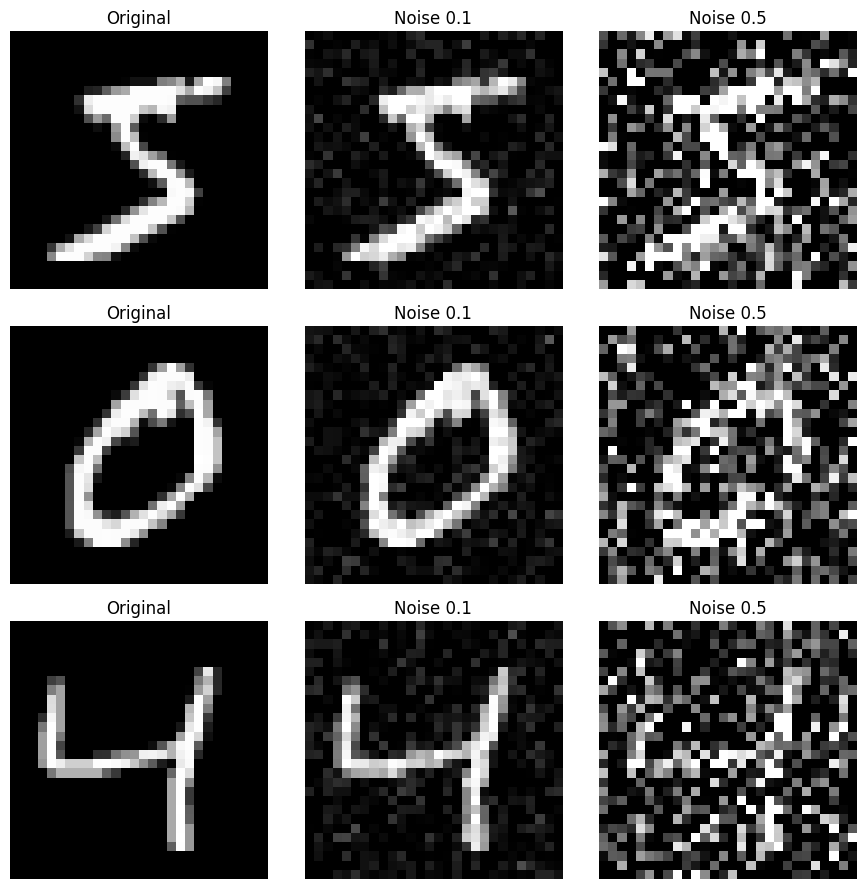

In [4]:
# STEP 1: Load, preprocess and add noise to MNIST dataset

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# 1. Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# 2. Normalize images to range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Reshape images to 28 x 28 x 1
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# 4. Add Gaussian noise
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_train_noisy_high = x_train + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_test_noisy_high = x_test + noise_factor_high * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

# 5. Clip pixel values between 0 and 1
x_train_noisy_low = np.clip(x_train_noisy_low, 0.0, 1.0)
x_train_noisy_high = np.clip(x_train_noisy_high, 0.0, 1.0)

x_test_noisy_low = np.clip(x_test_noisy_low, 0.0, 1.0)
x_test_noisy_high = np.clip(x_test_noisy_high, 0.0, 1.0)

# 6. Visualize original and noisy images
n = 3

plt.figure(figsize=(9, 9))

for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap="gray")
    plt.title("Noise 0.1")
    plt.axis("off")

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap="gray")
    plt.title("Noise 0.5")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# STEP 2: Build the Convolutional Denoising Autoencoder Model

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [6]:
# Encoder

def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    """

    input_img = Input(shape=input_shape, name="input")

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)

    return input_img, encoded

In [7]:
# Decoder

def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    """

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded_input)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)

    return decoded

In [8]:
# Complete Autoencoder

def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder.
    """

    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(
        inputs=input_img,
        outputs=decoded_output,
        name="autoencoder"
    )

    autoencoder.compile(
        optimizer=Adam(),
        loss="binary_crossentropy"
    )

    return autoencoder

In [9]:
# Compile and show model summary

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:


autoencoder = build_autoencoder()

history = autoencoder.fit(
    x_train_noisy_high[:10000],
    x_train[:10000],
    epochs=3,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy_high[:2000], x_test[:2000])
)

Epoch 1/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 38s 883ms/step - loss: 0.4008 - val_loss: 0.2135
Epoch 2/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 38s 821ms/step - loss: 0.1852 - val_loss: 0.1600
Epoch 3/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 798ms/step - loss: 0.1539 - val_loss: 0.1432


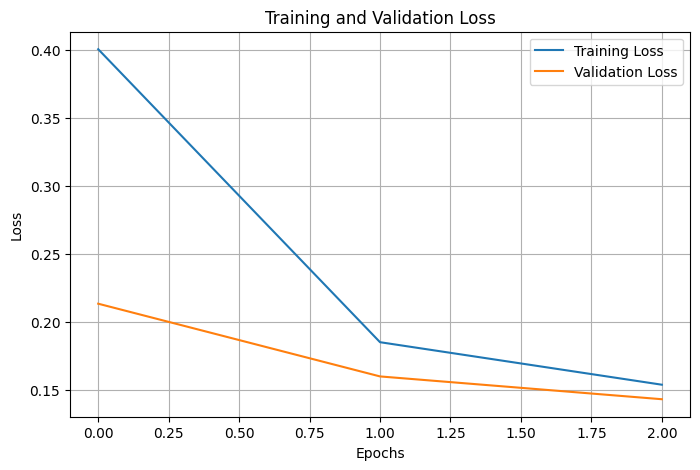

In [12]:
# Plot training and validation loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Predict denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


In [14]:
import matplotlib.pyplot as plt

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy Image
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        # Denoised Image
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

        # Clean Image
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap="gray")
        plt.title("Clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

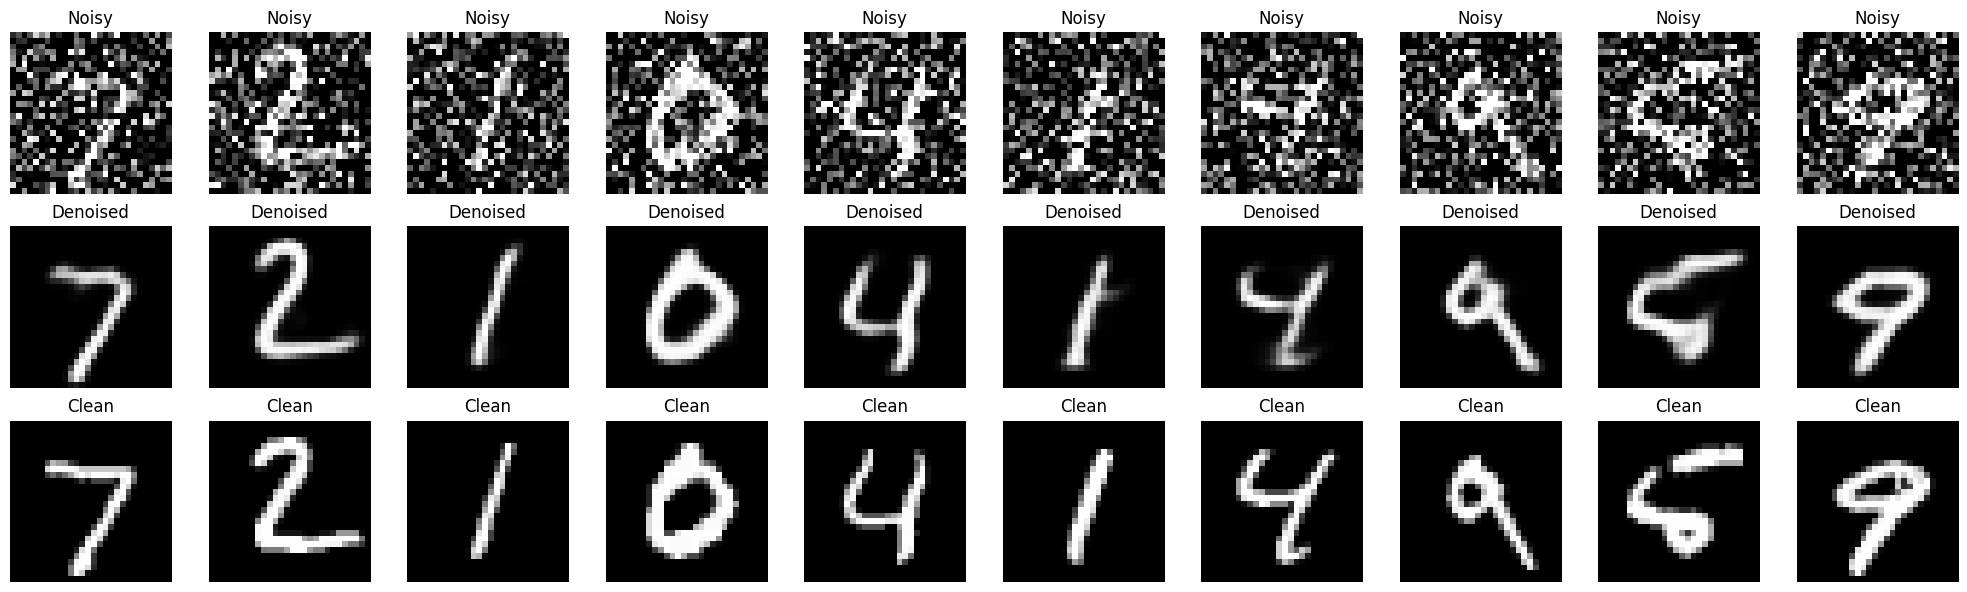

In [ ]:
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

#Exercise: Build a Denoising Convolutional Autoencoder

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

In [16]:
DATASET_DIR = "/content/devnagari_dataset/DevanagariHandwrittenDigitDataset"

IMG_SIZE = 32
NOISE_FACTOR = 0.5

In [22]:
import zipfile

# Extract ZIP file

zip_path = "/content/drive/MyDrive/6th sem AI/Data/Copy of devnagari digit.zip"
extract_path = "/content/devnagari_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully.")

Extracted successfully.


In [23]:
IMG_SIZE = 32
NOISE_FACTOR = 0.5

images = []
labels = []

class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Classes found:", class_names)
print("Number of classes:\n", len(class_names))

for label, class_name in enumerate(class_names):
    class_path = os.path.join(DATASET_DIR, class_name)

    for img_name in os.listdir(class_path):
        if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(class_path, img_name)

            img = Image.open(img_path).convert("L")
            img = img.resize((IMG_SIZE, IMG_SIZE))

            img_array = np.array(img)

            images.append(img_array)
            labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Classes found: ['Test', 'Train']
Number of classes:
 2
Images shape: (0,)
Labels shape: (0,)


In [24]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/6th sem AI/Data/Copy of devnagari digit.zip"
extract_path = "/content/devnagari_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("File extracted successfully!")
print("Extracted folders:", os.listdir(extract_path))

File extracted successfully!
Extracted folders: ['DevanagariHandwrittenDigitDataset']


In [25]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print("-" * 50)
    break

/content/devnagari_dataset
Folders: ['DevanagariHandwrittenDigitDataset']
Files: []
--------------------------------------------------


In [26]:
IMG_SIZE = 32
NOISE_FACTOR = 0.5

images = []
labels = []

# List 'Test' and 'Train' folders
split_folders = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Split folders found:", split_folders)

for split_folder_name in split_folders:
    split_folder_path = os.path.join(DATASET_DIR, split_folder_name)

    # List digit folders inside 'Train' or 'Test' (e.g., 'digit_0', 'digit_1', ...)
    digit_class_names = sorted([
        folder for folder in os.listdir(split_folder_path)
        if os.path.isdir(os.path.join(split_folder_path, folder))
    ])

    print(f"Digit classes in {split_folder_name}: {digit_class_names}")

    for label_idx, digit_class_name in enumerate(digit_class_names):
        digit_class_path = os.path.join(split_folder_path, digit_class_name)

        for img_name in os.listdir(digit_class_path):
            if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                img_path = os.path.join(digit_class_path, img_name)

                img = Image.open(img_path).convert("L")
                img = img.resize((IMG_SIZE, IMG_SIZE))

                img_array = np.array(img)

                images.append(img_array)
                labels.append(label_idx) # Use label_idx for the actual digit class

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)


Split folders found: ['Test', 'Train']
Digit classes in Test: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Digit classes in Train: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Images shape: (20000, 32, 32)
Labels shape: (20000,)


In [27]:
images = images.astype("float32") / 255.0

print("Min pixel value:", images.min())
print("Max pixel value:", images.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [28]:
images = np.reshape(images, (len(images), IMG_SIZE, IMG_SIZE, 1))

print("Reshaped images:", images.shape)

Reshaped images: (20000, 32, 32, 1)


In [29]:
x_train, x_val = train_test_split(
    images,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training data shape:", x_train.shape)
print("Validation data shape:", x_val.shape)

Training data shape: (16000, 32, 32, 1)
Validation data shape: (4000, 32, 32, 1)


In [30]:
x_train_noisy = x_train + NOISE_FACTOR * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_val_noisy = x_val + NOISE_FACTOR * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_val.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_val_noisy = np.clip(x_val_noisy, 0.0, 1.0)

print("Noisy train range:", x_train_noisy.min(), "to", x_train_noisy.max())
print("Noisy validation range:", x_val_noisy.min(), "to", x_val_noisy.max())

Noisy train range: 0.0 to 1.0
Noisy validation range: 0.0 to 1.0


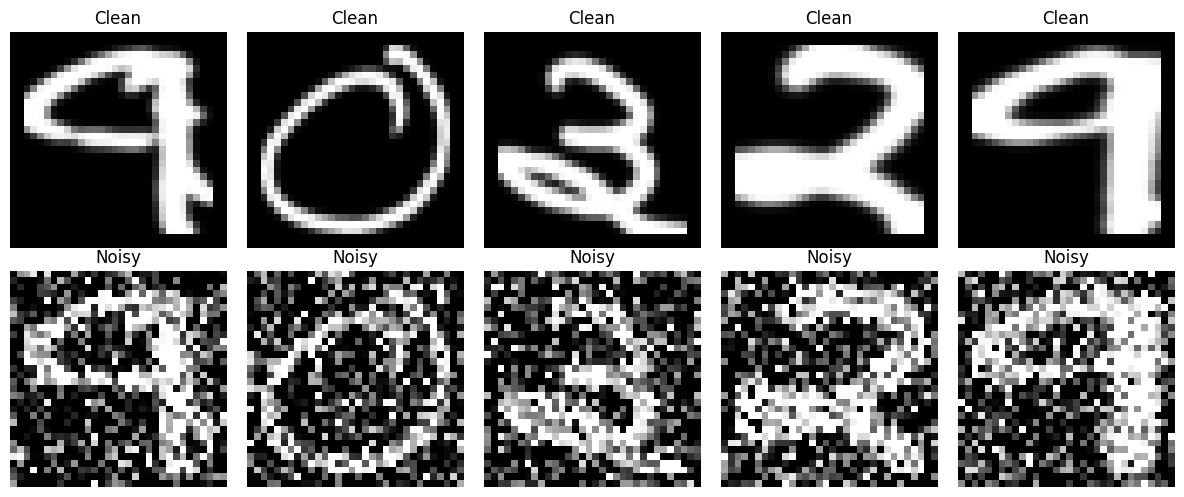

In [31]:
n = 5

plt.figure(figsize=(12, 5))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 2: Build Denoising Convolutional Autoencoder

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [33]:
def build_encoder(input_shape=(32, 32, 1)):
    input_img = keras.Input(shape=input_shape, name="input_image")

    # Layer 1
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)

    # Layer 2
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)

    # Layer 3
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)

    # Encoded output
    encoded = layers.Conv2D(256, (3, 3), activation="relu", padding="same", name="encoded_layer")(x)

    return input_img, encoded

In [34]:
def build_decoder(encoded_input):
    # Layer 4
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(encoded_input)

    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)

    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)

    decoded = layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same",
        name="decoded_output"
    )(x)

    return decoded

In [35]:
def build_autoencoder():
    input_img, encoded_output = build_encoder(input_shape=(32, 32, 1))
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(
        inputs=input_img,
        outputs=decoded_output,
        name="Devnagari_Denoising_Autoencoder"
    )

    autoencoder.compile(
        optimizer=Adam(),
        loss="binary_crossentropy"
    )

    return autoencoder

In [36]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "Devnagari_Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_layer (Conv2D)          │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775,425 (2.96 MB)

 Trainable params: 775,425 (2.96 MB)

 Non-trainable params: 0 (0.00 B)

STEP 3: Train the Denoising Autoencoder

In [ ]:
model_batch_exp = build_autoencoder()

history_batch_exp = model_batch_exp.fit(
    x_train_noisy[:5000],
    x_train[:5000],
    epochs=3,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy[:1000], x_val[:1000])
)

Epoch 1/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - loss: 0.0689 - val_loss: 0.0160
Epoch 2/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0097 - val_loss: 0.0075
Epoch 3/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0074 - val_loss: 0.0074


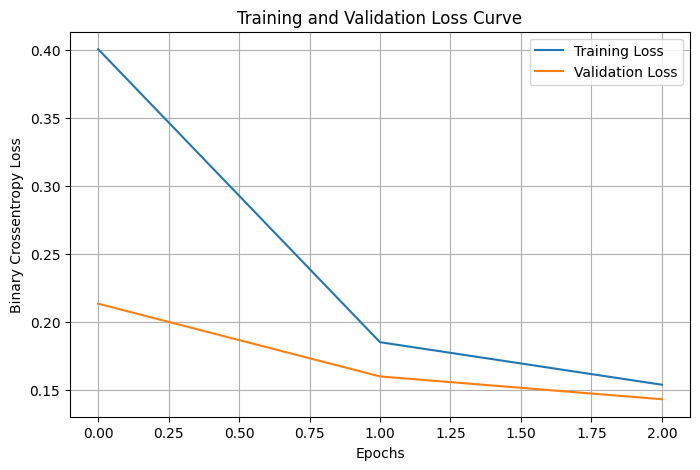

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(True)
plt.show()

STEP 4: Evaluate and Generate Denoised Images

In [38]:
# Generate denoised images from noisy validation images

denoised_images = autoencoder.predict(x_val_noisy)

print("Denoised images shape:", denoised_images.shape)

125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step
Denoised images shape: (4000, 32, 32, 1)


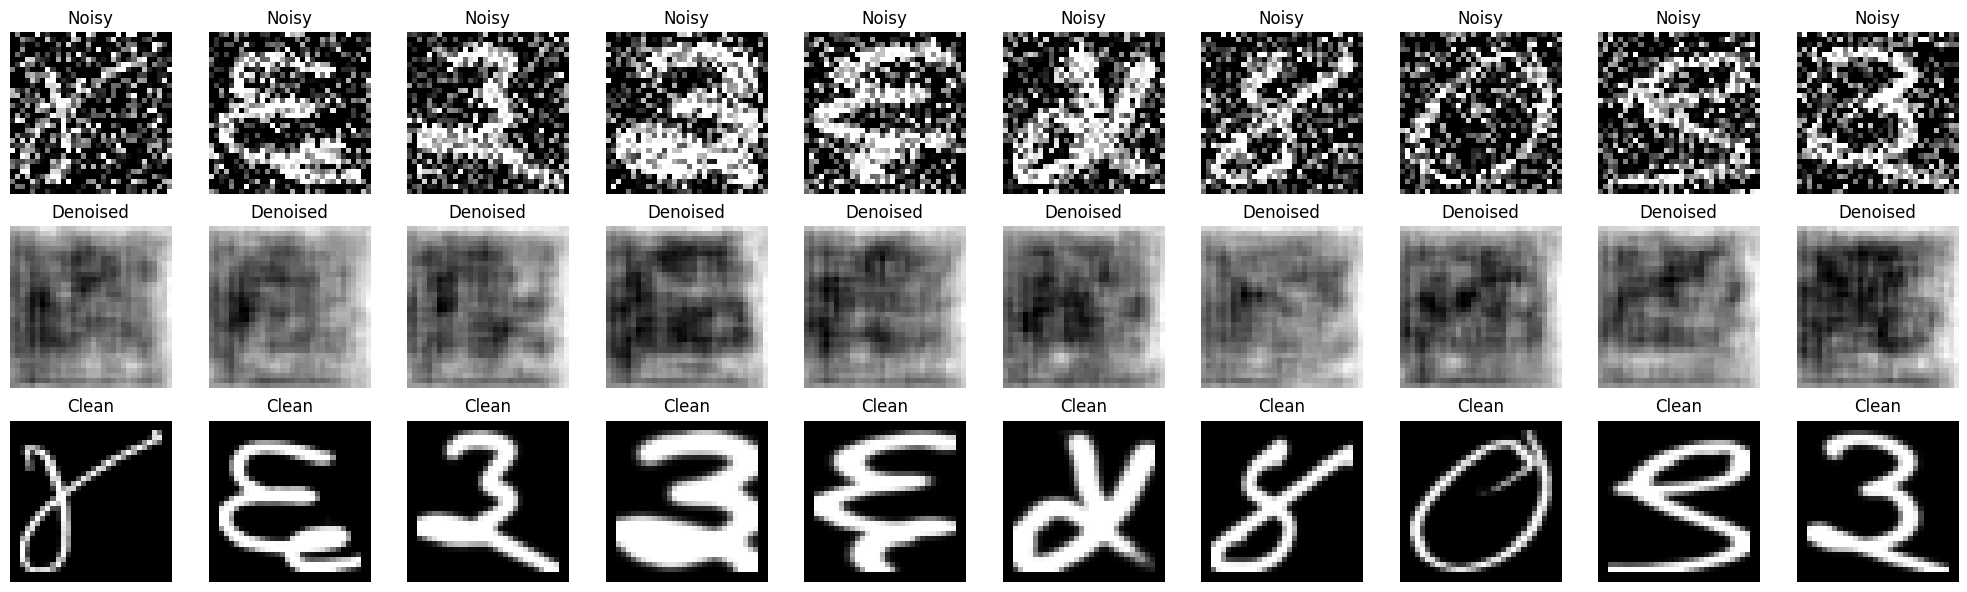

In [39]:
def plot_denoising_results(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy Image
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(32, 32), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        # Denoised Image
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(32, 32), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

        # Clean Image
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].reshape(32, 32), cmap="gray")
        plt.title("Clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


plot_denoising_results(x_val_noisy, denoised_images, x_val, n=10)

Answer / Observation

The denoising autoencoder was trained using noisy Devnagari images as input and the original clean images as target output. During training, the model learned to reconstruct clean images by minimizing the binary crossentropy loss between the denoised output and the original image.

The loss curve shows the model’s learning progress. A decreasing training and validation loss indicates that the model is improving its ability to remove noise. In the final visualization, the denoised images appear clearer than the noisy input images and are closer to the original clean images.

In [ ]:
# STEP 5: Experiment and Fine-Tune the Model

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# x_train, x_val are already defined from previous cells
# x_train, x_val = train_test_split(
#     test_size=0.2,
#     random_state=42,
#     shuffle=True
# )

print("Training data shape:", x_train.shape)
print("Validation data shape:", x_val.shape)

noise_levels = [0.2, 0.4, 0.6]
results = {}

# Use smaller subset to make experiment faster
x_train_small = x_train[:2000]
x_val_small = x_val[:400]

for noise in noise_levels:
    print(f"\nTraining with noise factor: {noise}")

    x_train_noisy_exp = x_train_small + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_train_small.shape
    )

    x_val_noisy_exp = x_val_small + noise * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_val_small.shape
    )

    x_train_noisy_exp = np.clip(x_train_noisy_exp, 0.0, 1.0)
    x_val_noisy_exp = np.clip(x_val_noisy_exp, 0.0, 1.0)

    model_exp = build_autoencoder()

    history_exp = model_exp.fit(
        x_train_noisy_exp,
        x_train_small,
        epochs=2,
        batch_size=256,
        shuffle=True,
        validation_data=(x_val_noisy_exp, x_val_small),
        verbose=1
    )

    val_loss = model_exp.evaluate(x_val_noisy_exp, x_val_small, verbose=0)
    results[noise] = val_loss

    print(f"Validation Loss for noise {noise}: {val_loss}")

print("\nFinal Results:")
print(results)